In [4]:
# ---------------------------------------------------------------------
# MULTI-YEAR HARMONIC INFORMATION-PARTITIONING INPUTS
#
# Pooled analysis years:
#   2016
#   2018
#   2025
#
# 2016 + 2025 are written by:
#   2016_2025_K2K3_Writer.ipynb
#
# 2018 uses the existing harmonic-sensitivity products.
# ---------------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ANALYSIS_YEARS = [2016, 2018, 2025]

INFO_DIR = Path(r"A:\NCA_DATA\Validation\Information_Partitioning")
HARMONIC_2018_DIR = Path(r"A:\NCA_DATA\Validation\2018_HarmonicSensitivity") / "Derived_AmpPhase_TIFs"

K2_FILES = {
    2016: INFO_DIR / "2016_K2_PlotLevel_InterceptAmpPhase.csv",
    2018: HARMONIC_2018_DIR / "2018_K2_PlotLevel_InterceptAmpPhase.csv",
    2025: INFO_DIR / "2025_K2_PlotLevel_InterceptAmpPhase.csv",
}

K3_FILES = {
    2016: INFO_DIR / "2016_K3_PlotLevel_InterceptAmpPhase.csv",
    2018: HARMONIC_2018_DIR / "2018_K3_PlotLevel_InterceptAmpPhase.csv",
    2025: INFO_DIR / "2025_K3_PlotLevel_InterceptAmpPhase.csv",
}

VEG_CSV = Path(r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg.csv")


In [5]:
# ---------------------------------------------------------------------
# LOAD + VALIDATE K2 / K3 HARMONIC TABLES
# ---------------------------------------------------------------------

def normalize_plot_id(series):

    return (
        series
        .astype(str)
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True,
        )
    )


def load_harmonic_tables(
    file_map,
    expected_order,
):

    tables = []

    reference_columns = None

    for year in ANALYSIS_YEARS:

        path = file_map[year]

        if not path.exists():

            raise FileNotFoundError(
                f"Missing {year} K{expected_order} file:\n"
                f"{path}"
            )


        df = pd.read_csv(
            path
        )


        # ---------------------------------------------------------
        # REQUIRED IDENTIFIERS
        # ---------------------------------------------------------

        required = [
            "PlotID",
            "Year",
            "HarmonicOrder",
            "X",
            "Y",
            "nobs",
        ]

        missing = [
            col
            for col in required
            if col not in df.columns
        ]

        if missing:

            raise KeyError(
                f"{year} K{expected_order} is missing "
                f"required columns: {missing}"
            )


        # ---------------------------------------------------------
        # NORMALIZE KEYS
        # ---------------------------------------------------------

        df["PlotID"] = normalize_plot_id(
            df["PlotID"]
        )

        df["Year"] = (
            pd.to_numeric(
                df["Year"],
                errors="raise",
            )
            .astype(int)
        )


        # ---------------------------------------------------------
        # NORMALIZE HARMONIC ORDER
        #
        # Accept:
        #
        #   2
        #   3
        #   "2"
        #   "3"
        #   "K2"
        #   "K3"
        #
        # and normalize all of them to integer 2 / 3.
        # ---------------------------------------------------------

        df["HarmonicOrder"] = (
            df["HarmonicOrder"]
            .astype(str)
            .str.strip()
            .str.upper()
            .str.replace(
                r"^K",
                "",
                regex=True,
            )
        )

        df["HarmonicOrder"] = (
            pd.to_numeric(
                df["HarmonicOrder"],
                errors="raise",
            )
            .astype(int)
        )


        # ---------------------------------------------------------
        # YEAR GUARD
        # ---------------------------------------------------------

        if not df["Year"].eq(
            year
        ).all():

            bad_years = sorted(
                df.loc[
                    ~df["Year"].eq(
                        year
                    ),
                    "Year",
                ]
                .unique()
                .tolist()
            )

            raise ValueError(
                f"{path.name} contains unexpected years: "
                f"{bad_years}"
            )


        # ---------------------------------------------------------
        # HARMONIC-ORDER GUARD
        # ---------------------------------------------------------

        if not df[
            "HarmonicOrder"
        ].eq(
            expected_order
        ).all():

            bad_orders = sorted(
                df.loc[
                    ~df[
                        "HarmonicOrder"
                    ].eq(
                        expected_order
                    ),
                    "HarmonicOrder",
                ]
                .unique()
                .tolist()
            )

            raise ValueError(
                f"{path.name} contains unexpected "
                f"harmonic orders: {bad_orders}"
            )


        # ---------------------------------------------------------
        # UNIQUE PLOT-YEAR GUARD
        # ---------------------------------------------------------

        duplicate_mask = (
            df.duplicated(
                subset=[
                    "PlotID",
                    "Year",
                ],
                keep=False,
            )
        )


        if duplicate_mask.any():

            display(
                df.loc[
                    duplicate_mask,
                    [
                        "PlotID",
                        "Year",
                    ],
                ]
                .sort_values(
                    [
                        "Year",
                        "PlotID",
                    ]
                )
            )

            raise ValueError(
                f"Duplicate PlotID-Year rows in "
                f"{path.name}"
            )


        # ---------------------------------------------------------
        # SCHEMA CONSISTENCY ACROSS YEARS
        # ---------------------------------------------------------

        current_columns = (
            df.columns.tolist()
        )


        if reference_columns is None:

            reference_columns = (
                current_columns
            )

        elif (
            current_columns
            !=
            reference_columns
        ):

            raise ValueError(
                f"Column schema/order mismatch in "
                f"{path.name}."
            )


        tables.append(
            df
        )


    return (
        pd.concat(
            tables,
            ignore_index=True,
        )
        .sort_values(
            [
                "Year",
                "PlotID",
            ]
        )
        .reset_index(
            drop=True
        )
    )


# ---------------------------------------------------------------------
# LOAD K2 + K3
# ---------------------------------------------------------------------

k2 = load_harmonic_tables(
    K2_FILES,
    expected_order=2,
)

k3 = load_harmonic_tables(
    K3_FILES,
    expected_order=3,
)


# ---------------------------------------------------------------------
# K2 / K3 POPULATION CONSISTENCY
# ---------------------------------------------------------------------

k2_keys = set(
    zip(
        k2["PlotID"],
        k2["Year"],
    )
)

k3_keys = set(
    zip(
        k3["PlotID"],
        k3["Year"],
    )
)


if (
    k2_keys
    !=
    k3_keys
):

    only_k2 = sorted(
        k2_keys
        -
        k3_keys
    )

    only_k3 = sorted(
        k3_keys
        -
        k2_keys
    )


    print(
        "Plot-years only in K2:",
        only_k2[:20],
    )

    print(
        "Plot-years only in K3:",
        only_k3[:20],
    )


    raise ValueError(
        "K2 and K3 do not contain the same "
        "PlotID-Year population."
    )


# ---------------------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------------------

print(
    "Combined K2:",
    k2.shape
)

print(
    "Combined K3:",
    k3.shape
)


print(
    "\nHarmonic rows by year:"
)

harmonic_counts = (
    k2
    .groupby(
        "Year"
    )
    .size()
)


for year in ANALYSIS_YEARS:

    print(
        f"  {year}: "
        f"{int(harmonic_counts.get(year, 0))}"
    )


print(
    "\nK2 columns:",
    len(k2.columns)
)

print(
    "K3 columns:",
    len(k3.columns)
)

Combined K2: (497, 96)
Combined K3: (497, 126)

Harmonic rows by year:
  2016: 257
  2018: 122
  2025: 118

K2 columns: 96
K3 columns: 126


In [6]:
# ---------------------------------------------------------------------
# LOAD VEGETATION DATA FOR ALL ANALYSIS YEARS
# AND JOIN BY PlotID + Year
# ---------------------------------------------------------------------

veg_raw = pd.read_csv(VEG_CSV)
veg_raw = veg_raw.rename(columns={"Plot": "PlotID"})

if "PlotID" not in veg_raw.columns:
    raise KeyError("Vegetation CSV does not contain 'Plot' or 'PlotID'.")
if "Year" not in veg_raw.columns:
    raise KeyError("Vegetation CSV does not contain a 'Year' column.")

veg_raw["PlotID"] = normalize_plot_id(veg_raw["PlotID"])
veg_raw["Year"] = pd.to_numeric(veg_raw["Year"], errors="raise").astype(int)

FUNCTIONAL_GROUPS = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]

required_cols = ["PlotID", "Year"] + FUNCTIONAL_GROUPS
missing = [col for col in required_cols if col not in veg_raw.columns]
if missing:
    raise KeyError(f"Vegetation table is missing expected columns: {missing}")

veg_years = veg_raw.loc[veg_raw["Year"].isin(ANALYSIS_YEARS)].copy()

print("Raw vegetation table:", veg_raw.shape)
print("Vegetation rows in analysis years:", veg_years.shape)
print("\nVegetation rows by year:")
for year in ANALYSIS_YEARS:
    print(f"  {year}: {int(veg_years["Year"].eq(year).sum())}")

duplicate_mask = veg_years.duplicated(subset=["PlotID", "Year"], keep=False)
print("\nDuplicate PlotID-Year rows:", int(duplicate_mask.sum()))
if duplicate_mask.any():
    display(veg_years.loc[duplicate_mask, required_cols].sort_values(["Year", "PlotID"]))
    raise ValueError("Duplicate PlotID-Year rows remain in vegetation data.")

veg = veg_years[required_cols].copy()

harmonic_keys = set(zip(k2["PlotID"], k2["Year"]))
veg_keys = set(zip(veg["PlotID"], veg["Year"]))
matched_keys = harmonic_keys & veg_keys
harmonic_only = harmonic_keys - veg_keys
veg_only = veg_keys - harmonic_keys

print("\nMatched harmonic + vegetation plot-years:", len(matched_keys))
print("Harmonic plot-years without vegetation:", len(harmonic_only))
print("Vegetation plot-years without harmonics:", len(veg_only))

match_rows = pd.DataFrame(list(matched_keys), columns=["PlotID", "Year"])
print("\nMatched plot-years by year:")
for year in ANALYSIS_YEARS:
    print(f"  {year}: {int(match_rows["Year"].eq(year).sum())}")

harmonic_only_df = pd.DataFrame(list(harmonic_only), columns=["PlotID", "Year"])
veg_only_df = pd.DataFrame(list(veg_only), columns=["PlotID", "Year"])

if len(harmonic_only_df) > 0:
    print("\nHarmonic-only counts by year:")
    print(harmonic_only_df.groupby("Year").size())

if len(veg_only_df) > 0:
    print("\nVegetation-only counts by year:")
    print(veg_only_df.groupby("Year").size())

k2_model = k2.merge(veg, on=["PlotID", "Year"], how="inner", validate="one_to_one")
k3_model = k3.merge(veg, on=["PlotID", "Year"], how="inner", validate="one_to_one")

print("\nK2 modeling table:", k2_model.shape)
print("K3 modeling table:", k3_model.shape)

k2_model_keys = set(zip(k2_model["PlotID"], k2_model["Year"]))
k3_model_keys = set(zip(k3_model["PlotID"], k3_model["Year"]))
assert k2_model_keys == k3_model_keys, "K2 and K3 modeling populations differ."

print("\nFinal modeling rows by year:")
for year in ANALYSIS_YEARS:
    print(f"  {year}: {int(k2_model["Year"].eq(year).sum())}")

print("\nFunctional-group availability:")
for fg in FUNCTIONAL_GROUPS:
    print(
        f"{fg:15s} "
        f"K2 n={k2_model[fg].notna().sum():3d} | "
        f"K3 n={k3_model[fg].notna().sum():3d} | "
        f"unique={k2_model[fg].nunique(dropna=True)}"
    )

display(k2_model[["PlotID", "Year"] + FUNCTIONAL_GROUPS].head())


Raw vegetation table: (717, 86)
Vegetation rows in analysis years: (717, 86)

Vegetation rows by year:
  2016: 365
  2018: 234
  2025: 118

Duplicate PlotID-Year rows: 0

Matched harmonic + vegetation plot-years: 492
Harmonic plot-years without vegetation: 5
Vegetation plot-years without harmonics: 225

Matched plot-years by year:
  2016: 257
  2018: 117
  2025: 118

Harmonic-only counts by year:
Year
2018    5
dtype: int64

Vegetation-only counts by year:
Year
2016    108
2018    117
dtype: int64

K2 modeling table: (492, 103)
K3 modeling table: (492, 133)

Final modeling rows by year:
  2016: 257
  2018: 117
  2025: 118

Functional-group availability:
BAREGROUND_FG   K2 n=492 | K3 n=492 | unique=299
BIOCRUST_FG     K2 n=492 | K3 n=492 | unique=194
EAG_FG          K2 n=492 | K3 n=492 | unique=268
EF_FG           K2 n=492 | K3 n=492 | unique=175
LITTER_FG       K2 n=492 | K3 n=492 | unique=222
PBG_FG          K2 n=492 | K3 n=492 | unique=201
SHRUB_total     K2 n=492 | K3 n=492 | unique

,PlotID,Year,BAREGROUND_FG,BIOCRUST_FG,EAG_FG,EF_FG,LITTER_FG,PBG_FG,SHRUB_total
0,100,2016,43.4,0.2,0.0,52.6,3.2,0.0,0.0
1,101,2016,41.4,5.6,8.6,33.6,9.0,0.0,0.0
2,102,2016,13.2,2.8,68.8,0.0,13.8,1.0,0.0
3,103,2016,28.8,5.2,42.4,0.0,22.2,0.0,0.0
4,104,2016,21.4,3.0,53.8,0.0,16.6,0.0,4.2


In [7]:
# ---------------------------------------------------------------------
# IDENTIFY INTERCEPT, AMPLITUDE, AND PHASE PREDICTOR BLOCKS
# ---------------------------------------------------------------------

def identify_iap_columns(df):

    intercept_cols = [
        c for c in df.columns
        if c.lower().startswith(("constant_", "intercept_"))
    ]

    amplitude_cols = [
        c for c in df.columns
        if c.lower().startswith(("amp", "amplitude"))
    ]

    phase_cols = [
        c for c in df.columns
        if c.lower().startswith("phase")
    ]

    return intercept_cols, amplitude_cols, phase_cols


K2_I, K2_A, K2_P = identify_iap_columns(k2_model)
K3_I, K3_A, K3_P = identify_iap_columns(k3_model)


# ------------------------------------------------------------
# QA COUNTS
# ------------------------------------------------------------

print("K2")
print("  Intercepts:", len(K2_I))
print("  Amplitudes:", len(K2_A))
print("  Phases:", len(K2_P))

print("\nK3")
print("  Intercepts:", len(K3_I))
print("  Amplitudes:", len(K3_A))
print("  Phases:", len(K3_P))


# ------------------------------------------------------------
# INSPECT ACTUAL COLUMN NAMES
# ------------------------------------------------------------

print("\nK2 intercept examples:")
print(K2_I[:10])

print("\nK2 amplitude examples:")
print(K2_A[:10])

print("\nK2 phase examples:")
print(K2_P[:10])

print("\nK3 third-order amplitude/phase examples:")
print([c for c in K3_A if "3" in c][:10])
print([c for c in K3_P if "3" in c][:10])

K2
  Intercepts: 15
  Amplitudes: 30
  Phases: 30

K3
  Intercepts: 15
  Amplitudes: 45
  Phases: 45

K2 intercept examples:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6', 'constant_B7', 'constant_B8', 'constant_B8A', 'constant_B11', 'constant_B12']

K2 amplitude examples:
['amp1_B2', 'amp1_B3', 'amp1_B4', 'amp1_B5', 'amp1_B6', 'amp1_B7', 'amp1_B8', 'amp1_B8A', 'amp1_B11', 'amp1_B12']

K2 phase examples:
['phase1_B2', 'phase1_B3', 'phase1_B4', 'phase1_B5', 'phase1_B6', 'phase1_B7', 'phase1_B8', 'phase1_B8A', 'phase1_B11', 'phase1_B12']

K3 third-order amplitude/phase examples:
['amp1_B3', 'amp2_B3', 'amp3_B2', 'amp3_B3', 'amp3_B4', 'amp3_B5', 'amp3_B6', 'amp3_B7', 'amp3_B8', 'amp3_B8A']
['phase1_B3', 'phase2_B3', 'phase3_B2', 'phase3_B3', 'phase3_B4', 'phase3_B5', 'phase3_B6', 'phase3_B7', 'phase3_B8', 'phase3_B8A']


In [8]:
# ---------------------------------------------------------------------
# BUILD THE SEVEN I / A / P MODEL PREDICTOR SETS
# ---------------------------------------------------------------------

K2_MODELS = {
    "I":   K2_I,
    "A":   K2_A,
    "P":   K2_P,
    "IA":  K2_I + K2_A,
    "IP":  K2_I + K2_P,
    "AP":  K2_A + K2_P,
    "IAP": K2_I + K2_A + K2_P,
}

K3_MODELS = {
    "I":   K3_I,
    "A":   K3_A,
    "P":   K3_P,
    "IA":  K3_I + K3_A,
    "IP":  K3_I + K3_P,
    "AP":  K3_A + K3_P,
    "IAP": K3_I + K3_A + K3_P,
}


# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("K2 predictor sets")
for name, cols in K2_MODELS.items():
    print(f"  {name:3s}: {len(cols):3d} predictors")

print("\nK3 predictor sets")
for name, cols in K3_MODELS.items():
    print(f"  {name:3s}: {len(cols):3d} predictors")


# More precise order-specific QA
print("\nK3 third-order amplitudes:", len(
    [c for c in K3_A if c.startswith("amp3_")]
))

print("K3 third-order phases:", len(
    [c for c in K3_P if c.startswith("phase3_")]
))

K2 predictor sets
  I  :  15 predictors
  A  :  30 predictors
  P  :  30 predictors
  IA :  45 predictors
  IP :  45 predictors
  AP :  60 predictors
  IAP:  75 predictors

K3 predictor sets
  I  :  15 predictors
  A  :  45 predictors
  P  :  45 predictors
  IA :  60 predictors
  IP :  60 predictors
  AP :  90 predictors
  IAP: 105 predictors

K3 third-order amplitudes: 15
K3 third-order phases: 15


In [9]:
# ---------------------------------------------------------------------
# INSPECT PHASE VALUE RANGES
#
# Writer convention:
#   atan2(sin, cos)
#   native phase range [-pi, pi]
# ---------------------------------------------------------------------

def phase_range_report(df, phase_cols, label):
    vals = df[phase_cols].to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]

    print(label)
    print("  min:", finite.min())
    print("  max:", finite.max())
    print("  mean:", finite.mean())
    print("  median:", np.median(finite))
    print()

phase_range_report(k2_model, K2_P, "K2 phase — pooled")
phase_range_report(k3_model, K3_P, "K3 phase — pooled")

for label, df, phase_cols in [("K2", k2_model, K2_P), ("K3", k3_model, K3_P)]:
    print("=" * 60)
    print(label)
    for year in ANALYSIS_YEARS:
        subset = df.loc[df["Year"].eq(year)]
        phase_range_report(subset, phase_cols, str(year))

for label, df, phase_cols in [("K2", k2_model, K2_P), ("K3", k3_model, K3_P)]:
    vals = df[phase_cols].to_numpy(dtype=float)
    finite = vals[np.isfinite(vals)]
    assert finite.min() >= -np.pi - 1e-10, f"{label} contains phase values below -pi."
    assert finite.max() <= np.pi + 1e-10, f"{label} contains phase values above pi."

print("Phase convention QA passed: all K2/K3 phase values are within [-pi, pi].")


K2 phase — pooled
  min: -3.141165608351831
  max: 3.1412207530700664
  mean: -0.08093237940618321
  median: 0.2746312528785796

K3 phase — pooled
  min: -3.1412444
  max: 3.1415515
  mean: -0.30458167039734274
  median: -0.7118533688858331

K2
2016
  min: -3.141165608351831
  max: 3.140816952513933
  mean: -0.17194875693335923
  median: -0.031402974580701

2018
  min: -3.1396117
  max: 3.1400623
  mean: -0.13198179538100577
  median: -0.127155725

2025
  min: -3.140242341271479
  max: 3.1412207530700664
  mean: 0.16748237718333922
  median: 0.8921040688079088

K3
2016
  min: -3.140831343264845
  max: 3.141494728720042
  mean: -0.3773243053864141
  median: -0.821320451239742

2018
  min: -3.1412444
  max: 3.1415515
  mean: -0.5851630145613985
  median: -1.2615846

2025
  min: -3.1410663888197883
  max: 3.1408375536912763
  mean: 0.12967505091809628
  median: 0.48628678798853187

Phase convention QA passed: all K2/K3 phase values are within [-pi, pi].


In [10]:
# ---------------------------------------------------------------------
# CONVERT PHASE ANGLES TO CIRCULAR SIN/COS PREDICTORS
# ---------------------------------------------------------------------

def circularize_phase_columns(df, phase_cols):
    out = df.copy()
    circular_cols = []

    for col in phase_cols:
        sin_col = f"{col}_sin"
        cos_col = f"{col}_cos"

        out[sin_col] = np.sin(out[col].astype(float))
        out[cos_col] = np.cos(out[col].astype(float))

        circular_cols.extend([sin_col, cos_col])

    return out, circular_cols


k2_model, K2_P_CIRC = circularize_phase_columns(
    k2_model,
    K2_P,
)

k3_model, K3_P_CIRC = circularize_phase_columns(
    k3_model,
    K3_P,
)


print("K2 raw phase columns:", len(K2_P))
print("K2 circular phase predictors:", len(K2_P_CIRC))

print("\nK3 raw phase columns:", len(K3_P))
print("K3 circular phase predictors:", len(K3_P_CIRC))

K2 raw phase columns: 30
K2 circular phase predictors: 60

K3 raw phase columns: 45
K3 circular phase predictors: 90


In [26]:
K2_MODELS = {
    "I": K2_I,
    "A": K2_A,
    "P": K2_P_CIRC,
    "IA": K2_I + K2_A,
    "IP": K2_I + K2_P_CIRC,
    "AP": K2_A + K2_P_CIRC,
    "IAP": K2_I + K2_A + K2_P_CIRC,
}

K3_MODELS = {
    "I": K3_I,
    "A": K3_A,
    "P": K3_P_CIRC,
    "IA": K3_I + K3_A,
    "IP": K3_I + K3_P_CIRC,
    "AP": K3_A + K3_P_CIRC,
    "IAP": K3_I + K3_A + K3_P_CIRC,
}

# ---------------------------------------------------------------------
# QA DIMENSIONALITY
# ---------------------------------------------------------------------

N_K2 = len(k2_model)
N_K3 = len(k3_model)

print(f"K2 observations: {N_K2}")
print(f"K3 observations: {N_K3}")

print("\nObservations by year:")
for year in ANALYSIS_YEARS:
    print(f"  {year}: {int(k2_model["Year"].eq(year).sum())}")

print("\nK2 predictor sets")
for name, cols in K2_MODELS.items():
    p = len(cols)
    print(
        f"  {name:3s}: {p:3d} predictors | "
        f"p/n = {p / N_K2:.3f} | "
        f"n/p = {N_K2 / p:.3f} | "
        f"n-p = {N_K2 - p:+d}"
    )

print("\nK3 predictor sets")
for name, cols in K3_MODELS.items():
    p = len(cols)
    print(
        f"  {name:3s}: {p:3d} predictors | "
        f"p/n = {p / N_K3:.3f} | "
        f"n/p = {N_K3 / p:.3f} | "
        f"n-p = {N_K3 - p:+d}"
    )


K2 observations: 492
K3 observations: 492

Observations by year:
  2016: 257
  2018: 117
  2025: 118

K2 predictor sets
  I  :  15 predictors | p/n = 0.030 | n/p = 32.800 | n-p = +477
  A  :  30 predictors | p/n = 0.061 | n/p = 16.400 | n-p = +462
  P  :  60 predictors | p/n = 0.122 | n/p = 8.200 | n-p = +432
  IA :  45 predictors | p/n = 0.091 | n/p = 10.933 | n-p = +447
  IP :  75 predictors | p/n = 0.152 | n/p = 6.560 | n-p = +417
  AP :  90 predictors | p/n = 0.183 | n/p = 5.467 | n-p = +402
  IAP: 105 predictors | p/n = 0.213 | n/p = 4.686 | n-p = +387

K3 predictor sets
  I  :  15 predictors | p/n = 0.030 | n/p = 32.800 | n-p = +477
  A  :  45 predictors | p/n = 0.091 | n/p = 10.933 | n-p = +447
  P  :  90 predictors | p/n = 0.183 | n/p = 5.467 | n-p = +402
  IA :  60 predictors | p/n = 0.122 | n/p = 8.200 | n-p = +432
  IP : 105 predictors | p/n = 0.213 | n/p = 4.686 | n-p = +387
  AP : 135 predictors | p/n = 0.274 | n/p = 3.644 | n-p = +357
  IAP: 150 predictors | p/n = 0.305 |

In [20]:
# ---------------------------------------------------------------------
# SIMPLE K-FOLD BETA REGRESSION
# ---------------------------------------------------------------------

def beta_cv(
    df,
    response,
    predictors,
):

    # -------------------------------------------------------------
    # COMPLETE CASES
    # -------------------------------------------------------------

    dat = (
        df[
            [response]
            +
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )


    X = (
        dat[
            predictors
        ]
        .to_numpy(
            dtype=float
        )
    )


    y = (
        dat[
            response
        ]
        .to_numpy(
            dtype=float
        )
        /
        100.0
    )


    # -------------------------------------------------------------
    # BETA BOUNDARY ADJUSTMENT
    # -------------------------------------------------------------

    n = len(y)

    y = (
        y * (n - 1)
        +
        0.5
    ) / n


    # -------------------------------------------------------------
    # OUT-OF-FOLD PREDICTIONS
    # -------------------------------------------------------------

    pred = np.full(
        n,
        np.nan,
    )


    for train, test in CV.split(X):

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X[train]
        )


        X_test = scaler.transform(
            X[test]
        )


        X_train = sm.add_constant(
            X_train,
            has_constant="add",
        )


        X_test = sm.add_constant(
            X_test,
            has_constant="add",
        )


        fit = BetaModel(
            y[train],
            X_train,
        ).fit(
            disp=False,
        )


        pred[test] = fit.predict(
            X_test
        )


    # -------------------------------------------------------------
    # RESULTS
    # -------------------------------------------------------------

    return {

        "n":
            n,

        "p":
            len(
                predictors
            ),

        "cv_r2":
            r2_score(
                y,
                pred,
            ),

        "cv_rmse":
            mean_squared_error(
                y,
                pred,
            ) ** 0.5,
    }

In [21]:
results = []

for name, predictors in K2_MODELS.items():

    result = beta_cv(
        k2_model,
        "EAG_FG",
        predictors,
    )

    result["order"] = "K2"
    result["model"] = name

    results.append(
        result
    )


pd.DataFrame(
    results
)

,n,p,cv_r2,cv_rmse,order,model
0,491,15,0.533813,0.196735,K2,I
1,491,30,0.497962,0.204160,K2,A
2,491,30,0.102801,0.272927,K2,P
3,491,45,0.592289,0.183983,K2,IA
4,491,45,0.555017,0.192209,K2,IP
5,491,60,0.500786,0.203585,K2,AP
6,491,75,0.581147,0.186480,K2,IAP


In [29]:
# ---------------------------------------------------------------------
# BETA REGRESSION CV:
# ALL FUNCTIONAL GROUPS × BOTH HARMONIC ORDERS × ALL I/A/P PARTITIONS
# ---------------------------------------------------------------------

all_beta_results = []


ORDER_CONFIG = {
    "K2": {
        "df": k2_model,
        "models": K2_MODELS,
    },
    "K3": {
        "df": k3_model,
        "models": K3_MODELS,
    },
}


for order, config in ORDER_CONFIG.items():

    df = config["df"]
    model_sets = config["models"]

    print(
        "\n" + "=" * 70
    )
    print(
        order
    )


    for response in FUNCTIONAL_GROUPS:

        print(
            f"\n{response}"
        )


        for model_name, predictors in model_sets.items():

            print(
                f"  {model_name}"
            )


            result = beta_cv(
                df=df,
                response=response,
                predictors=predictors,
            )


            result["order"] = order

            result["functional_group"] = response

            result["model"] = model_name


            all_beta_results.append(
                result
            )


# ---------------------------------------------------------------------
# COMBINE RESULTS
# ---------------------------------------------------------------------

all_beta_results = pd.DataFrame(
    all_beta_results
)


all_beta_results = all_beta_results[
    [
        "order",
        "functional_group",
        "model",
        "n",
        "p",
        "cv_r2",
        "cv_rmse",
        "loglik",
        "aic"
    ]
]


# ---------------------------------------------------------------------
# SORT
# ---------------------------------------------------------------------

model_order = [
    "I",
    "A",
    "P",
    "IA",
    "IP",
    "AP",
    "IAP",
]


all_beta_results["model"] = pd.Categorical(
    all_beta_results["model"],
    categories=model_order,
    ordered=True,
)


all_beta_results = (
    all_beta_results
    .sort_values(
        [
            "functional_group",
            "order",
            "model",
        ]
    )
    .reset_index(
        drop=True
    )
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
):
    display(
        all_beta_results
    )


K2

BAREGROUND_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

BIOCRUST_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

EAG_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

EF_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

LITTER_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

PBG_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

SHRUB_total
  I
  A
  P
  IA
  IP
  AP
  IAP

K3

BAREGROUND_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

BIOCRUST_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

EAG_FG
  I
  A
  P
  IA


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  IP
  AP
  IAP


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\scottfordham\


EF_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

LITTER_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

PBG_FG
  I
  A
  P
  IA
  IP
  AP
  IAP

SHRUB_total
  I
  A
  P
  IA
  IP
  AP


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  IAP


,order,functional_group,model,n,p,cv_r2,cv_rmse,loglik,aic
0,K2,BAREGROUND_FG,I,491,15,0.604269,0.120663,494.274395,-954.548791
1,K2,BAREGROUND_FG,A,491,30,0.394102,0.149304,413.966432,-763.932863
2,K2,BAREGROUND_FG,P,491,30,0.069583,0.185017,318.083002,-572.166004
3,K2,BAREGROUND_FG,IA,491,45,0.568134,0.126051,526.628688,-959.257376
4,K2,BAREGROUND_FG,IP,491,45,0.556237,0.127776,521.373056,-948.746112
5,K2,BAREGROUND_FG,AP,491,60,0.323873,0.157720,444.556987,-765.113973
6,K2,BAREGROUND_FG,IAP,491,75,0.526154,0.132036,554.438232,-954.876465
7,K3,BAREGROUND_FG,I,491,15,0.619934,0.118250,505.336684,-976.673368
8,K3,BAREGROUND_FG,A,491,45,0.380339,0.150991,443.381061,-792.762123
9,K3,BAREGROUND_FG,P,491,45,0.040557,0.187881,339.442475,-584.884951


In [27]:
# ---------------------------------------------------------------------
# SIMPLE K-FOLD BETA REGRESSION
# WITH FULL-DATA LOGLIK + AIC
# ---------------------------------------------------------------------

def beta_cv(
    df,
    response,
    predictors,
):

    # -------------------------------------------------------------
    # COMPLETE CASES
    # -------------------------------------------------------------

    dat = (
        df[
            [response]
            +
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )


    X = (
        dat[
            predictors
        ]
        .to_numpy(
            dtype=float
        )
    )


    y_original = (
        dat[
            response
        ]
        .to_numpy(
            dtype=float
        )
        /
        100.0
    )


    # -------------------------------------------------------------
    # BETA BOUNDARY ADJUSTMENT
    # -------------------------------------------------------------

    n = len(
        y_original
    )


    y_beta = (
        y_original
        *
        (n - 1)
        +
        0.5
    ) / n


    # -------------------------------------------------------------
    # OUT-OF-FOLD PREDICTIONS
    # -------------------------------------------------------------

    pred = np.full(
        n,
        np.nan,
    )


    for train, test in CV.split(X):

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X[train]
        )


        X_test = scaler.transform(
            X[test]
        )


        X_train = sm.add_constant(
            X_train,
            has_constant="add",
        )


        X_test = sm.add_constant(
            X_test,
            has_constant="add",
        )


        fit = BetaModel(
            y_beta[train],
            X_train,
        ).fit(
            disp=False,
        )


        pred[test] = fit.predict(
            X_test
        )


    # -------------------------------------------------------------
    # CROSS-VALIDATED PREDICTIVE METRICS
    #
    # Evaluate against ORIGINAL response proportions.
    # -------------------------------------------------------------

    cv_r2 = r2_score(
        y_original,
        pred,
    )


    cv_rmse = (
        mean_squared_error(
            y_original,
            pred,
        )
        ** 0.5
    )


    # -------------------------------------------------------------
    # FULL-DATA BETA MODEL
    #
    # Used only for model-native fit metrics:
    #   log-likelihood
    #   AIC
    # -------------------------------------------------------------

    scaler_full = StandardScaler()


    X_full = scaler_full.fit_transform(
        X
    )


    X_full = sm.add_constant(
        X_full,
        has_constant="add",
    )


    full_fit = BetaModel(
        y_beta,
        X_full,
    ).fit(
        disp=False,
    )


    # -------------------------------------------------------------
    # RESULTS
    # -------------------------------------------------------------

    return {

        "n":
            n,

        "p":
            len(
                predictors
            ),

        "cv_r2":
            cv_r2,

        "cv_rmse":
            cv_rmse,

        "loglik":
            full_fit.llf,

        "aic":
            full_fit.aic,
    }

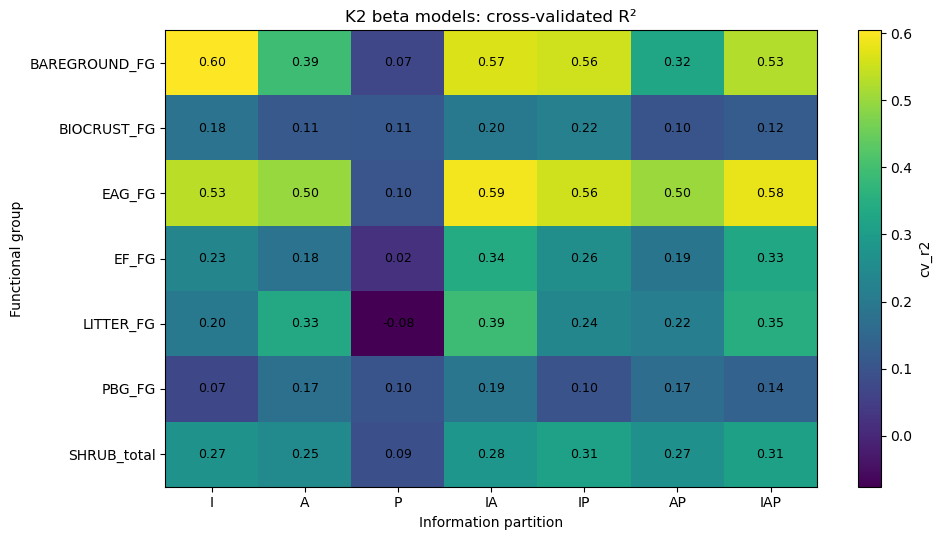

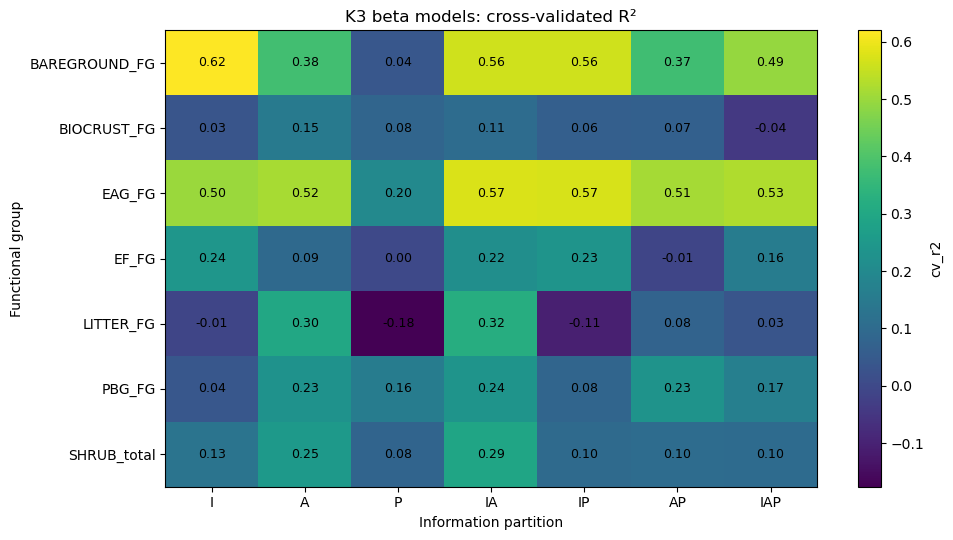

In [28]:
# ---------------------------------------------------------------------
# HEATMAPS OF BETA-MODEL CV R²
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_ORDER = ["I", "A", "P", "IA", "IP", "AP", "IAP"]

FG_ORDER = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]


def plot_metric_heatmap(df, value_col, title, row_order, col_order, decimals=2):
    pivot = (
        df.pivot(
            index="functional_group",
            columns="model",
            values=value_col,
        )
        .reindex(index=row_order, columns=col_order)
    )

    values = pivot.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    im = ax.imshow(values, aspect="auto")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_title(title)
    ax.set_xlabel("Information partition")
    ax.set_ylabel("Functional group")

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.{decimals}f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(value_col)

    plt.tight_layout()
    plt.show()


# K2 heatmap
plot_metric_heatmap(
    df=all_beta_results.loc[all_beta_results["order"] == "K2"],
    value_col="cv_r2",
    title="K2 beta models: cross-validated R²",
    row_order=FG_ORDER,
    col_order=MODEL_ORDER,
    decimals=2,
)

# K3 heatmap
plot_metric_heatmap(
    df=all_beta_results.loc[all_beta_results["order"] == "K3"],
    value_col="cv_r2",
    title="K3 beta models: cross-validated R²",
    row_order=FG_ORDER,
    col_order=MODEL_ORDER,
    decimals=2,
)

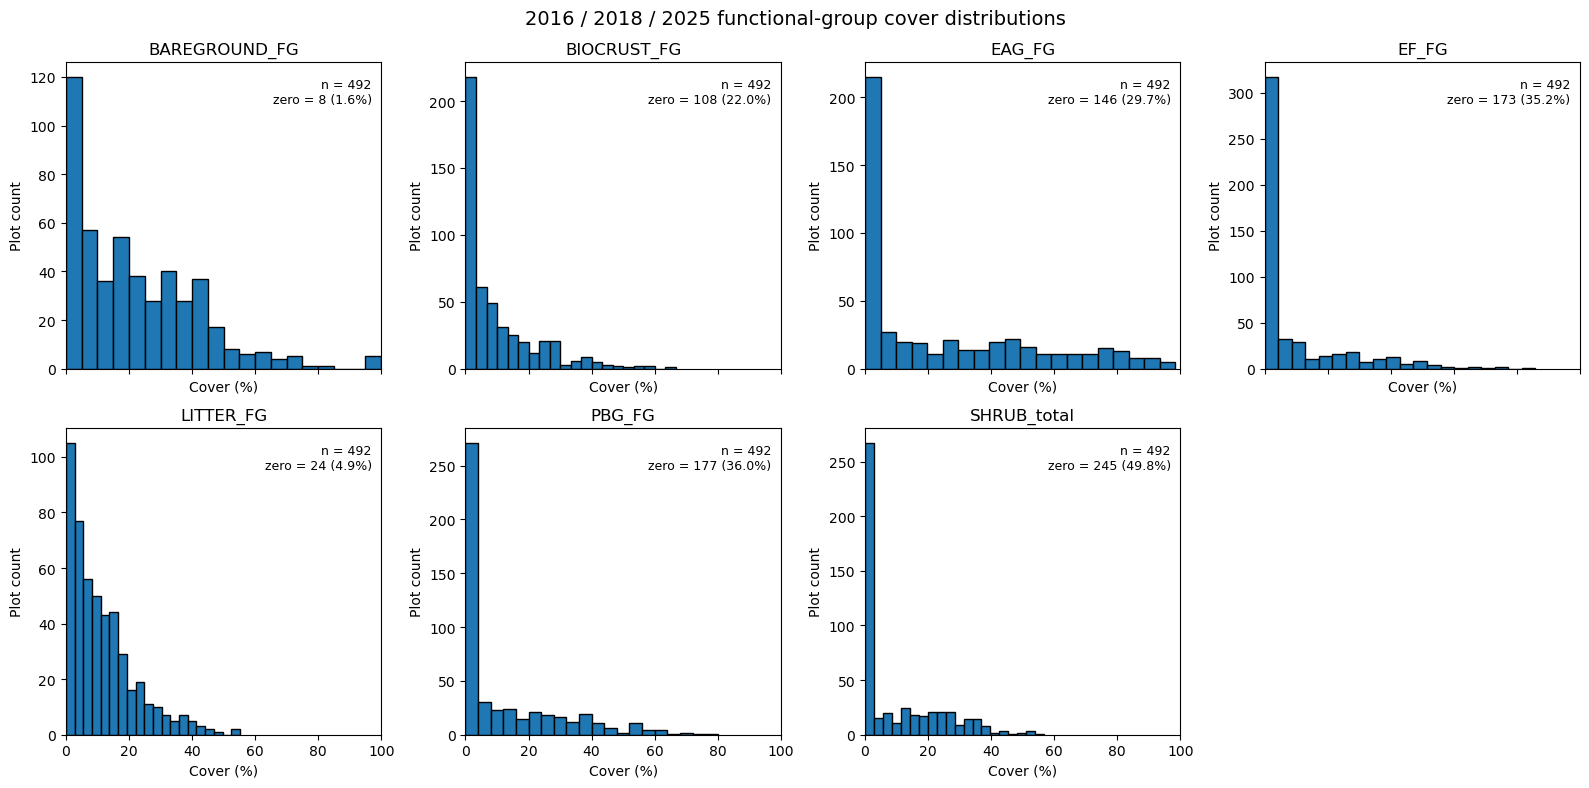

In [17]:
# ---------------------------------------------------------------------
# HISTOGRAMS OF FUNCTIONAL-GROUP COVER
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

FUNCTIONAL_GROUPS = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
    sharex=True,
)

axes = axes.ravel()

for ax, fg in zip(axes, FUNCTIONAL_GROUPS):

    values = (
        k2_model[fg]
        .dropna()
        .astype(float)
    )

    ax.hist(
        values,
        bins=20,
        edgecolor="black",
    )

    ax.set_title(fg)
    ax.set_xlabel("Cover (%)")
    ax.set_ylabel("Plot count")
    ax.set_xlim(0, 100)

    # Helpful for evaluating zero inflation
    n = len(values)
    n_zero = (values == 0).sum()

    ax.text(
        0.97,
        0.95,
        f"n = {n}\nzero = {n_zero} ({100*n_zero/n:.1f}%)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
    )


# Remove unused 8th panel
axes[-1].axis("off")

fig.suptitle(
    "2016 / 2018 / 2025 functional-group cover distributions",
    fontsize=14,
)

plt.tight_layout()
plt.show()


Beta models showed that 2nd order IA models were generally optimal; lets look at dirichlet compositional vector approach:

In [24]:
# ---------------------------------------------------------------------
# DIRICHLET REGRESSION CV
# IA REPRESENTATION — K2 vs K3
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

from scipy.optimize import minimize
from scipy.special import gammaln, softmax
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler


CV = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


def prepare_composition(df, response_cols):

    Y = (
        df[response_cols]
        .to_numpy(float)
    )

    # Percent -> proportion
    Y = Y / 100.0

    # Small pseudocount for structural zeros
    eps = 1e-4

    Y = Y + eps

    # Close each composition to sum to 1
    Y = (
        Y
        /
        Y.sum(axis=1, keepdims=True)
    )

    return Y


def dirichlet_nll(params, X, Y):

    n, p = X.shape
    k = Y.shape[1]

    # K-1 linear predictors; final component is reference
    B = params[:-1].reshape(
        p,
        k - 1,
    )

    log_phi = params[-1]

    eta = X @ B

    eta = np.column_stack(
        [
            eta,
            np.zeros(n),
        ]
    )

    mu = softmax(
        eta,
        axis=1,
    )

    phi = np.exp(
        log_phi
    )

    alpha = (
        mu
        *
        phi
    )

    ll = (
        gammaln(phi)
        -
        np.sum(
            gammaln(alpha),
            axis=1,
        )
        +
        np.sum(
            (alpha - 1)
            *
            np.log(Y),
            axis=1,
        )
    )

    return -np.sum(ll)


def dirichlet_cv(
    df,
    predictors,
    response_cols,
):

    # -------------------------------------------------------------
    # COMPLETE CASES
    # -------------------------------------------------------------

    dat = (
        df[
            predictors
            +
            response_cols
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )


    X = dat[
        predictors
    ].to_numpy(float)


    Y = prepare_composition(
        dat,
        response_cols,
    )


    n = len(Y)
    k = len(response_cols)


    pred = np.full_like(
        Y,
        np.nan,
        dtype=float,
    )


    for train, test in CV.split(X):

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X[train]
        )

        X_test = scaler.transform(
            X[test]
        )


        # Add intercept
        X_train = np.column_stack(
            [
                np.ones(len(train)),
                X_train,
            ]
        )

        X_test = np.column_stack(
            [
                np.ones(len(test)),
                X_test,
            ]
        )


        p = X_train.shape[1]


        # Initial coefficients = 0
        # Initial precision phi = 20
        start = np.zeros(
            p * (k - 1) + 1
        )

        start[-1] = np.log(
            20.0
        )


        fit = minimize(
            dirichlet_nll,
            start,
            args=(
                X_train,
                Y[train],
            ),
            method="L-BFGS-B",
            options={
                "maxiter": 5000,
            },
        )


        B = fit.x[:-1].reshape(
            p,
            k - 1,
        )


        eta = X_test @ B


        eta = np.column_stack(
            [
                eta,
                np.zeros(
                    len(test)
                ),
            ]
        )


        pred[test] = softmax(
            eta,
            axis=1,
        )


    # -------------------------------------------------------------
    # COMPOSITIONAL PREDICTION ERROR
    #
    # Root mean squared error over all components.
    # -------------------------------------------------------------

    rmse = np.sqrt(
        np.mean(
            (
                Y
                -
                pred
            ) ** 2
        )
    )


    # Mean absolute compositional error
    mae = np.mean(
        np.abs(
            Y
            -
            pred
        )
    )


    return {
        "n":
            n,

        "p":
            len(predictors),

        "dirichlet_rmse":
            rmse,

        "dirichlet_mae":
            mae,
    }

In [25]:
dirichlet_results = []


for order, df, predictors in [

    (
        "K2",
        k2_model,
        K2_MODELS["IA"],
    ),

    (
        "K3",
        k3_model,
        K3_MODELS["IA"],
    ),

]:

    result = dirichlet_cv(
        df=df,
        predictors=predictors,
        response_cols=FUNCTIONAL_GROUPS,
    )

    result["order"] = order

    dirichlet_results.append(
        result
    )


dirichlet_results = pd.DataFrame(
    dirichlet_results
)


display(
    dirichlet_results
)

,n,p,dirichlet_rmse,dirichlet_mae,order
0,491,45,0.137317,0.097566,K2
1,491,60,0.139631,0.098273,K3


dirichlet is not great, but we expected that. optical information is not readily encoding functional groups at this stage. 

In [30]:
# ---------------------------------------------------------------------
# HURDLE BETA MODEL
#
# Stage 1:
#   Logistic regression for occurrence:
#       P(cover > 0)
#
# Stage 2:
#   Beta regression for positive cover:
#       E(cover | cover > 0)
#
# Combined:
#   Expected cover =
#       P(presence) * E(cover | presence)
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

import statsmodels.api as sm

from statsmodels.othermod.betareg import BetaModel

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    r2_score,
    mean_squared_error,
)

In [31]:
# ---------------------------------------------------------------------
# 5-FOLD HURDLE BETA CV
# ---------------------------------------------------------------------

HURDLE_CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


def hurdle_beta_cv(
    df,
    response,
    predictors,
):

    # -------------------------------------------------------------
    # COMPLETE CASES
    # -------------------------------------------------------------

    dat = (
        df[
            [response]
            +
            predictors
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )


    X = (
        dat[
            predictors
        ]
        .to_numpy(
            dtype=float
        )
    )


    # original 0-1 cover
    y = (
        dat[
            response
        ]
        .to_numpy(
            dtype=float
        )
        /
        100.0
    )


    # binary occurrence
    present = (
        y > 0
    ).astype(int)


    n = len(y)
    n_positive = int(
        present.sum()
    )


    # -------------------------------------------------------------
    # STORAGE
    # -------------------------------------------------------------

    presence_pred = np.full(
        n,
        np.nan,
    )


    positive_cover_pred = np.full(
        n,
        np.nan,
    )


    hurdle_pred = np.full(
        n,
        np.nan,
    )


    # -------------------------------------------------------------
    # CROSS-VALIDATION
    # -------------------------------------------------------------

    for train, test in HURDLE_CV.split(
        X,
        present,
    ):

        # ---------------------------------------------------------
        # STANDARDIZE USING TRAINING DATA ONLY
        # ---------------------------------------------------------

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X[train]
        )


        X_test = scaler.transform(
            X[test]
        )


        # =========================================================
        # STAGE 1:
        # LOGISTIC OCCURRENCE MODEL
        # =========================================================

        occurrence_model = LogisticRegression(
            max_iter=5000,
        )


        occurrence_model.fit(
            X_train,
            present[train],
        )


        p_presence = (
            occurrence_model
            .predict_proba(
                X_test
            )[:, 1]
        )


        presence_pred[test] = (
            p_presence
        )


        # =========================================================
        # STAGE 2:
        # BETA MODEL ON POSITIVE TRAINING OBSERVATIONS
        # =========================================================

        train_positive = (
            present[train] == 1
        )


        X_beta_train = (
            X_train[
                train_positive
            ]
        )


        y_beta_train_original = (
            y[train][
                train_positive
            ]
        )


        n_beta = len(
            y_beta_train_original
        )


        # ---------------------------------------------------------
        # Move positive boundary values into (0,1)
        #
        # Mostly relevant if any observed cover = 100%.
        # ---------------------------------------------------------

        y_beta_train = (
            y_beta_train_original
            *
            (n_beta - 1)
            +
            0.5
        ) / n_beta


        X_beta_train = sm.add_constant(
            X_beta_train,
            has_constant="add",
        )


        X_beta_test = sm.add_constant(
            X_test,
            has_constant="add",
        )


        beta_fit = BetaModel(
            y_beta_train,
            X_beta_train,
        ).fit(
            disp=False,
        )


        conditional_cover = (
            beta_fit.predict(
                X_beta_test
            )
        )


        positive_cover_pred[test] = (
            conditional_cover
        )


        # =========================================================
        # COMBINED HURDLE EXPECTATION
        #
        # E(Y|X) =
        # P(Y>0|X) *
        # E(Y|Y>0,X)
        # =========================================================

        hurdle_pred[test] = (
            p_presence
            *
            conditional_cover
        )


    # -------------------------------------------------------------
    # STAGE 1 PERFORMANCE:
    # OCCURRENCE
    # -------------------------------------------------------------

    occurrence_auc = roc_auc_score(
        present,
        presence_pred,
    )


    occurrence_logloss = log_loss(
        present,
        presence_pred,
    )


    # -------------------------------------------------------------
    # STAGE 2 PERFORMANCE:
    # COVER CONDITIONAL ON PRESENCE
    #
    # Evaluate only observations that actually contain the group.
    # -------------------------------------------------------------

    observed_positive = (
        present == 1
    )


    positive_r2 = r2_score(
        y[
            observed_positive
        ],
        positive_cover_pred[
            observed_positive
        ],
    )


    positive_rmse = (
        mean_squared_error(
            y[
                observed_positive
            ],
            positive_cover_pred[
                observed_positive
            ],
        )
        ** 0.5
    )


    # -------------------------------------------------------------
    # FULL HURDLE PERFORMANCE:
    # ALL OBSERVATIONS
    #
    # This evaluates the combined expected-cover prediction.
    # -------------------------------------------------------------

    hurdle_r2 = r2_score(
        y,
        hurdle_pred,
    )


    hurdle_rmse = (
        mean_squared_error(
            y,
            hurdle_pred,
        )
        ** 0.5
    )


    # -------------------------------------------------------------
    # RETURN
    # -------------------------------------------------------------

    return {

        "n":
            n,

        "n_positive":
            n_positive,

        "zero_fraction":
            1
            -
            n_positive / n,

        "p":
            len(
                predictors
            ),

        "occurrence_auc":
            occurrence_auc,

        "occurrence_logloss":
            occurrence_logloss,

        "positive_cv_r2":
            positive_r2,

        "positive_cv_rmse":
            positive_rmse,

        "hurdle_cv_r2":
            hurdle_r2,

        "hurdle_cv_rmse":
            hurdle_rmse,
    }

In [33]:
# ---------------------------------------------------------------------
# RUN HURDLE MODELS:
# K2 IA vs K3 IA
# ---------------------------------------------------------------------

hurdle_results = []


for order, df_model, predictor_sets in [

    (
        "K2",
        k2_model,
        K2_MODELS,
    ),

    (
        "K3",
        k3_model,
        K3_MODELS,
    ),

]:

    predictors = predictor_sets["IA"]


    for fg in FUNCTIONAL_GROUPS:

        print(
            f"{order} | "
            f"{fg} | IA"
        )


        result = hurdle_beta_cv(
            df=df_model,
            response=fg,
            predictors=predictors,
        )


        result["order"] = order
        result["functional_group"] = fg
        result["model"] = "IA"


        hurdle_results.append(
            result
        )


hurdle_results = pd.DataFrame(
    hurdle_results
)


hurdle_results = hurdle_results[
    [
        "order",
        "functional_group",
        "model",
        "n",
        "n_positive",
        "zero_fraction",
        "p",
        "occurrence_auc",
        "occurrence_logloss",
        "positive_cv_r2",
        "positive_cv_rmse",
        "hurdle_cv_r2",
        "hurdle_cv_rmse",
    ]
]


display(
    hurdle_results
)

K2 | BAREGROUND_FG | IA
K2 | BIOCRUST_FG | IA
K2 | EAG_FG | IA
K2 | EF_FG | IA
K2 | LITTER_FG | IA
K2 | PBG_FG | IA
K2 | SHRUB_total | IA
K3 | BAREGROUND_FG | IA
K3 | BIOCRUST_FG | IA
K3 | EAG_FG | IA
K3 | EF_FG | IA
K3 | LITTER_FG | IA
K3 | PBG_FG | IA
K3 | SHRUB_total | IA


,order,functional_group,model,n,n_positive,zero_fraction,p,occurrence_auc,occurrence_logloss,positive_cv_r2,positive_cv_rmse,hurdle_cv_r2,hurdle_cv_rmse
0,K2,BAREGROUND_FG,IA,491,483,0.016293,45,0.709369,0.095905,0.575782,0.124607,0.572342,0.125436
1,K2,BIOCRUST_FG,IA,491,384,0.217923,45,0.750560,0.495578,0.147135,0.116783,0.205321,0.109689
2,K2,EAG_FG,IA,491,346,0.295316,45,0.851704,0.430237,0.582870,0.184189,0.632736,0.174975
3,K2,EF_FG,IA,491,318,0.352342,45,0.700749,0.601100,0.342976,0.140869,0.363140,0.124441
4,K2,LITTER_FG,IA,491,468,0.046843,45,0.840951,0.155449,0.354385,0.083124,0.380528,0.081934
5,K2,PBG_FG,IA,491,315,0.358452,45,0.687320,0.611207,0.113160,0.169575,0.180776,0.154107
6,K2,SHRUB_total,IA,491,247,0.496945,45,0.831851,0.531298,0.042418,0.120174,0.302259,0.109393
7,K3,BAREGROUND_FG,IA,491,483,0.016293,60,0.627329,0.102362,0.595029,0.121748,0.602496,0.120933
8,K3,BIOCRUST_FG,IA,491,384,0.217923,60,0.746763,0.519523,0.171056,0.115133,0.155104,0.113101
9,K3,EAG_FG,IA,491,346,0.295316,60,0.852701,0.432403,0.535143,0.194441,0.611198,0.180033


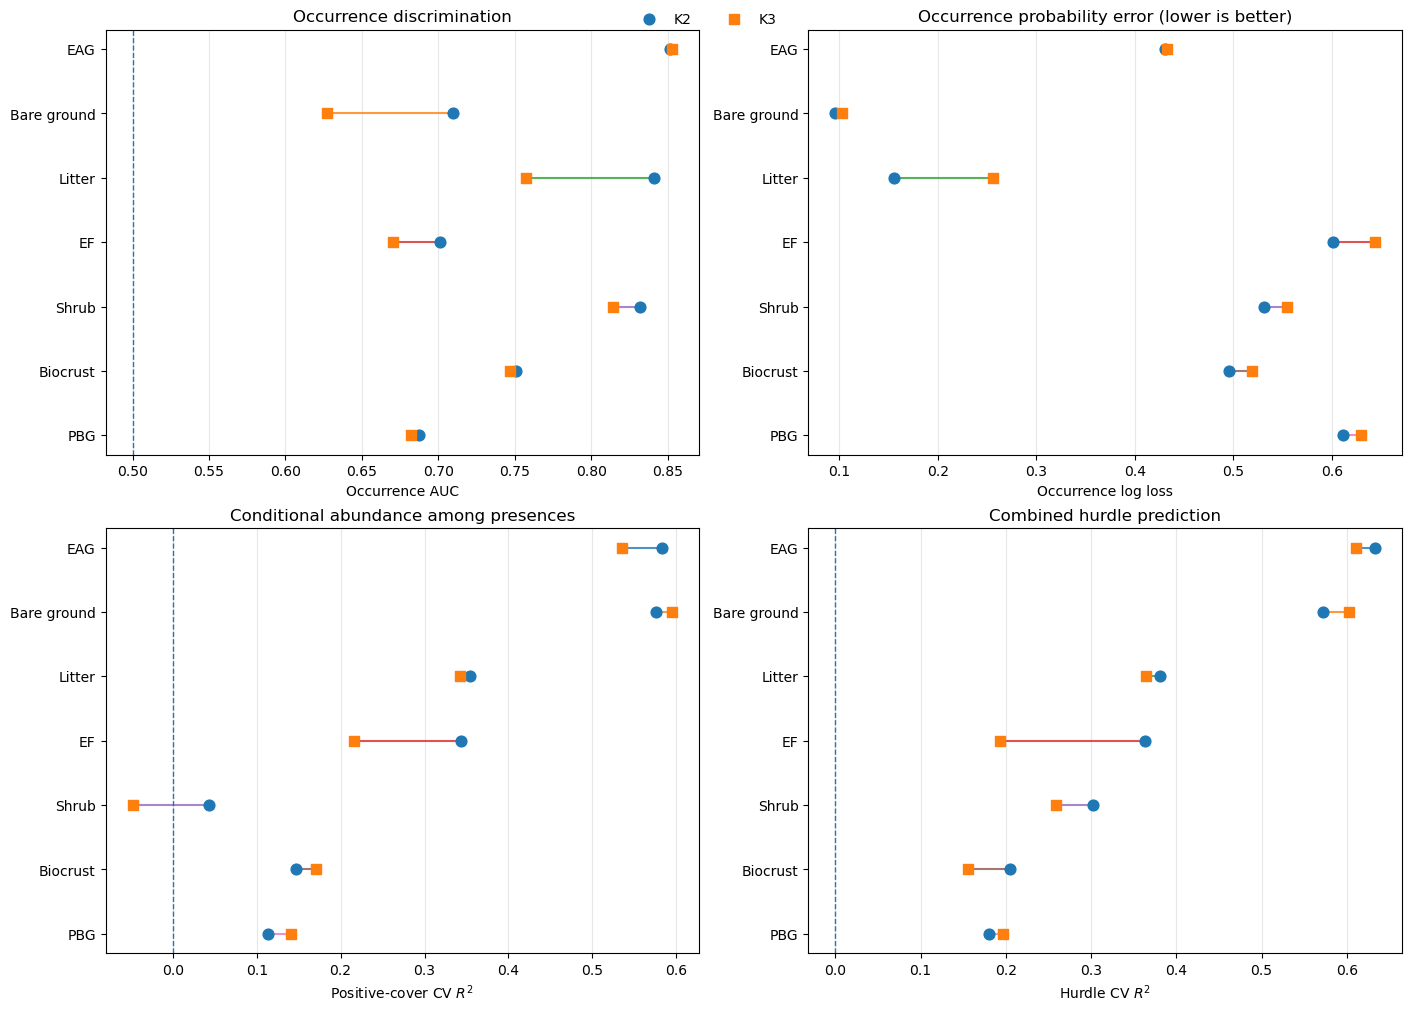

In [34]:
# ---------------------------------------------------------------------
# FIGURE: HURDLE MODEL PERFORMANCE
# Paired K2 vs K3 comparison by functional group
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# COPY + CLEAN
# ---------------------------------------------------------------------
plot_df = hurdle_results.copy()

# keep the IA hurdle results only if other model rows get added later
plot_df = plot_df.loc[plot_df["model"] == "IA"].copy()

# order functional groups by K2 hurdle R2 for intuitive reading
order_fg = (
    plot_df.loc[plot_df["order"] == "K2", ["functional_group", "hurdle_cv_r2"]]
    .sort_values("hurdle_cv_r2", ascending=False)["functional_group"]
    .tolist()
)

plot_df["functional_group"] = pd.Categorical(
    plot_df["functional_group"],
    categories=order_fg,
    ordered=True,
)

plot_df = plot_df.sort_values(["functional_group", "order"]).copy()

# nicer labels
fg_label_map = {
    "BAREGROUND_FG": "Bare ground",
    "BIOCRUST_FG": "Biocrust",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "LITTER_FG": "Litter",
    "PBG_FG": "PBG",
    "SHRUB_total": "Shrub",
}

plot_df["fg_label"] = plot_df["functional_group"].map(fg_label_map)

# y positions
fg_levels = [fg for fg in order_fg]
fg_labels = [fg_label_map.get(fg, fg) for fg in fg_levels]
ypos = np.arange(len(fg_levels))

# ---------------------------------------------------------------------
# HELPER FOR ONE PANEL
# ---------------------------------------------------------------------
def paired_metric_panel(ax, data, metric, xlabel, higher_is_better=True):
    k2 = (
        data.loc[data["order"] == "K2", ["functional_group", metric]]
        .set_index("functional_group")
        .reindex(fg_levels)
    )
    k3 = (
        data.loc[data["order"] == "K3", ["functional_group", metric]]
        .set_index("functional_group")
        .reindex(fg_levels)
    )

    x_k2 = k2[metric].to_numpy()
    x_k3 = k3[metric].to_numpy()

    # connecting lines
    for i in range(len(ypos)):
        ax.plot(
            [x_k2[i], x_k3[i]],
            [ypos[i], ypos[i]],
            linewidth=1.5,
            alpha=0.8,
        )

    # points
    ax.scatter(
        x_k2,
        ypos,
        s=60,
        label="K2",
        marker="o",
        zorder=3,
    )
    ax.scatter(
        x_k3,
        ypos,
        s=60,
        label="K3",
        marker="s",
        zorder=3,
    )

    ax.set_yticks(ypos)
    ax.set_yticklabels(fg_labels)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)
    ax.invert_yaxis()

    # light reference boundaries where helpful
    if metric == "occurrence_auc":
        ax.axvline(0.5, linestyle="--", linewidth=1)
    if metric in ["positive_cv_r2", "hurdle_cv_r2"]:
        ax.axvline(0.0, linestyle="--", linewidth=1)

    # put "better" side in an intuitive direction if desired
    if not higher_is_better:
        # for log loss, smaller is better, so we still keep natural x-axis,
        # but annotate in title instead of reversing axis
        pass


# ---------------------------------------------------------------------
# BUILD FIGURE
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

paired_metric_panel(
    axes[0, 0],
    plot_df,
    metric="occurrence_auc",
    xlabel="Occurrence AUC",
    higher_is_better=True,
)
axes[0, 0].set_title("Occurrence discrimination")

paired_metric_panel(
    axes[0, 1],
    plot_df,
    metric="occurrence_logloss",
    xlabel="Occurrence log loss",
    higher_is_better=False,
)
axes[0, 1].set_title("Occurrence probability error (lower is better)")

paired_metric_panel(
    axes[1, 0],
    plot_df,
    metric="positive_cv_r2",
    xlabel="Positive-cover CV $R^2$",
    higher_is_better=True,
)
axes[1, 0].set_title("Conditional abundance among presences")

paired_metric_panel(
    axes[1, 1],
    plot_df,
    metric="hurdle_cv_r2",
    xlabel="Hurdle CV $R^2$",
    higher_is_better=True,
)
axes[1, 1].set_title("Combined hurdle prediction")

# one shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)

plt.show()

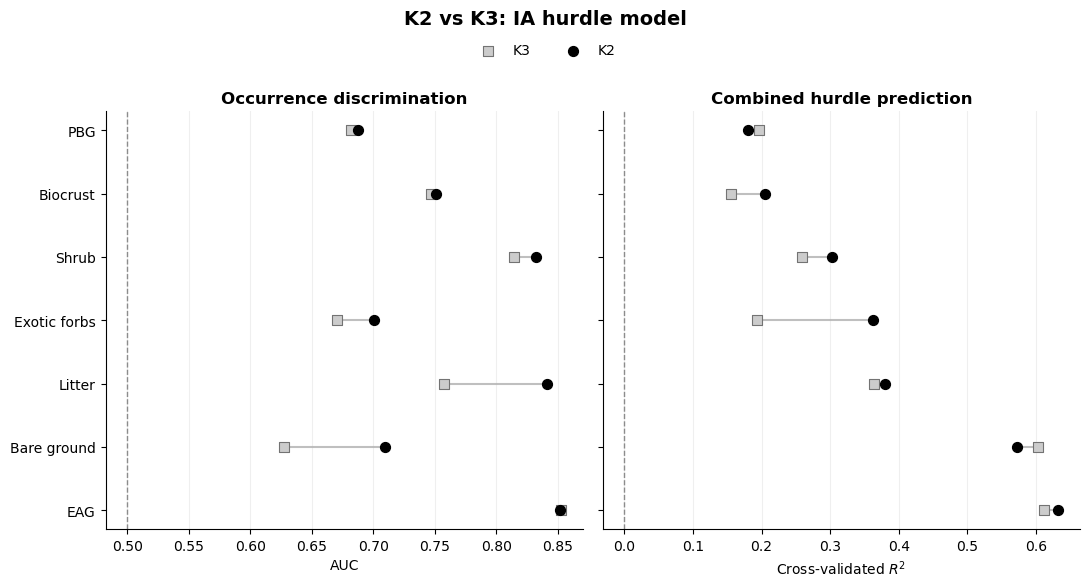

In [39]:
# ---------------------------------------------------------------------
# CLEAN K2 vs K3 COMPARISON
# IA HURDLE MODEL
#
# Zero process:
#   Bernoulli / logistic model for P(Y = 0)
#
# Positive process:
#   Beta regression for Y | Y > 0
#
# Figure shows:
#   1. Occurrence discrimination (AUC)
#   2. Combined hurdle prediction (CV R²)
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# PREP
# ---------------------------------------------------------------------

plot_df = hurdle_results.copy()

plot_df = plot_df.loc[
    plot_df["model"] == "IA"
].copy()

fg_label_map = {
    "BAREGROUND_FG": "Bare ground",
    "BIOCRUST_FG": "Biocrust",
    "EAG_FG": "EAG",
    "EF_FG": "Exotic forbs",
    "LITTER_FG": "Litter",
    "PBG_FG": "PBG",
    "SHRUB_total": "Shrub",
}

# order by K2 combined hurdle performance
fg_order = (
    plot_df.loc[
        plot_df["order"] == "K2",
        ["functional_group", "hurdle_cv_r2"]
    ]
    .sort_values(
        "hurdle_cv_r2",
        ascending=False
    )["functional_group"]
    .tolist()
)

fg_labels = [
    fg_label_map.get(fg, fg)
    for fg in fg_order
]

y = np.arange(
    len(fg_order)
)

# ---------------------------------------------------------------------
# HELPER
# ---------------------------------------------------------------------

def paired_panel(
    ax,
    metric,
    title,
    xlabel,
    reference=None
):

    k2 = (
        plot_df.loc[
            plot_df["order"] == "K2",
            ["functional_group", metric]
        ]
        .set_index("functional_group")
        .reindex(fg_order)[metric]
        .to_numpy()
    )

    k3 = (
        plot_df.loc[
            plot_df["order"] == "K3",
            ["functional_group", metric]
        ]
        .set_index("functional_group")
        .reindex(fg_order)[metric]
        .to_numpy()
    )

    # paired connector
    for i in range(len(y)):
        ax.plot(
            [k2[i], k3[i]],
            [y[i], y[i]],
            color="0.75",
            linewidth=1.5,
            zorder=1
        )

    # K3 first so K2 stays visually dominant
    ax.scatter(
        k3,
        y,
        marker="s",
        s=45,
        facecolor="0.80",
        edgecolor="0.45",
        linewidth=0.8,
        label="K3",
        zorder=2
    )

    ax.scatter(
        k2,
        y,
        marker="o",
        s=50,
        facecolor="black",
        edgecolor="black",
        label="K2",
        zorder=3
    )

    if reference is not None:
        ax.axvline(
            reference,
            linestyle="--",
            linewidth=1,
            color="0.55"
        )

    ax.set_title(
        title,
        fontweight="bold"
    )

    ax.set_xlabel(
        xlabel
    )

    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        fg_labels
    )

    ax.invert_yaxis()

    ax.grid(
        axis="x",
        alpha=0.20
    )

    ax.grid(
        axis="y",
        visible=False
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)


# ---------------------------------------------------------------------
# FIGURE
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5.5),
    sharey=True
)

paired_panel(
    axes[0],
    metric="occurrence_auc",
    title="Occurrence discrimination",
    xlabel="AUC",
    reference=0.5
)

paired_panel(
    axes[1],
    metric="hurdle_cv_r2",
    title="Combined hurdle prediction",
    xlabel="Cross-validated $R^2$",
    reference=0.0
)

# restore y labels on left panel only
axes[1].tick_params(
    labelleft=False
)

# shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "K2 vs K3: IA hurdle model",
    fontsize=14,
    fontweight="bold",
    y=1.06
)

plt.tight_layout()

plt.show()

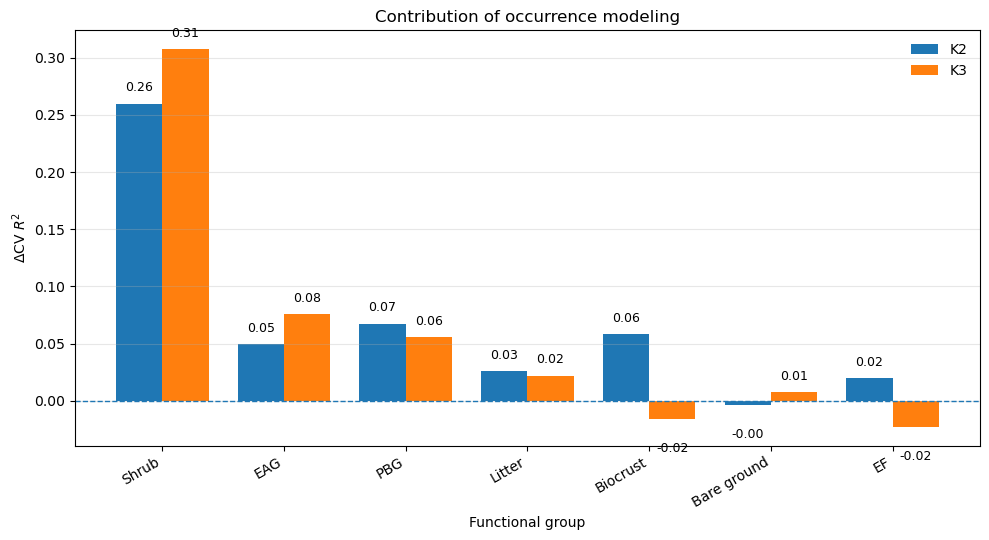

In [36]:
# ---------------------------------------------------------------------
# FIGURE: OCCURRENCE CONTRIBUTION TO COVER PREDICTION
# grouped bars of delta R2 = hurdle_cv_r2 - positive_cv_r2
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = hurdle_results.copy()
plot_df = plot_df.loc[plot_df["model"] == "IA"].copy()

plot_df["delta_r2"] = (
    plot_df["hurdle_cv_r2"] - plot_df["positive_cv_r2"]
)

label_map = {
    "BAREGROUND_FG": "Bare ground",
    "BIOCRUST_FG": "Biocrust",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "LITTER_FG": "Litter",
    "PBG_FG": "PBG",
    "SHRUB_total": "Shrub",
}

plot_df["fg_label"] = plot_df["functional_group"].map(label_map)

# sort by mean delta across K2 and K3
fg_order = (
    plot_df.groupby("fg_label")["delta_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

wide = (
    plot_df.pivot(
        index="fg_label",
        columns="order",
        values="delta_r2",
    )
    .reindex(fg_order)
)

x = np.arange(len(wide.index))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    x - bar_width / 2,
    wide["K2"],
    width=bar_width,
    label="K2",
)

ax.bar(
    x + bar_width / 2,
    wide["K3"],
    width=bar_width,
    label="K3",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(wide.index, rotation=30, ha="right")
ax.set_ylabel(r"$\Delta$CV $R^2$")
ax.set_xlabel("Functional group")
ax.set_title("Contribution of occurrence modeling")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.3)

# annotate values
for i, fg in enumerate(wide.index):
    for j, order in enumerate(["K2", "K3"]):
        val = wide.loc[fg, order]
        xpos = i - bar_width / 2 if order == "K2" else i + bar_width / 2
        ax.text(
            xpos,
            val + 0.008 if val >= 0 else val - 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom" if val >= 0 else "top",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

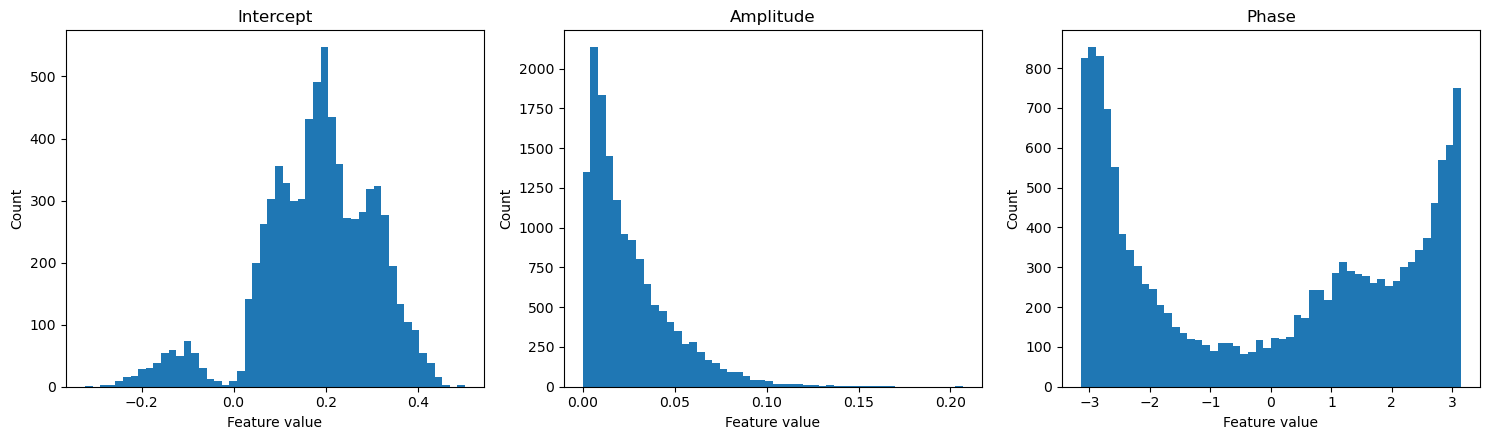

In [37]:
# ---------------------------------------------------------------------
# DISTRIBUTIONS OF K2 INTERCEPT / AMPLITUDE / PHASE FEATURES
# POOLED 2016 + 2018 + 2025
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

blocks = {
    "Intercept": K2_I,
    "Amplitude": K2_A,
    "Phase": K2_P,
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)

for ax, (label, cols) in zip(
    axes,
    blocks.items(),
):

    values = (
        k2_model[cols]
        .to_numpy(dtype=float)
        .ravel()
    )

    values = values[
        np.isfinite(values)
    ]

    ax.hist(
        values,
        bins=50,
    )

    ax.set_title(label)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

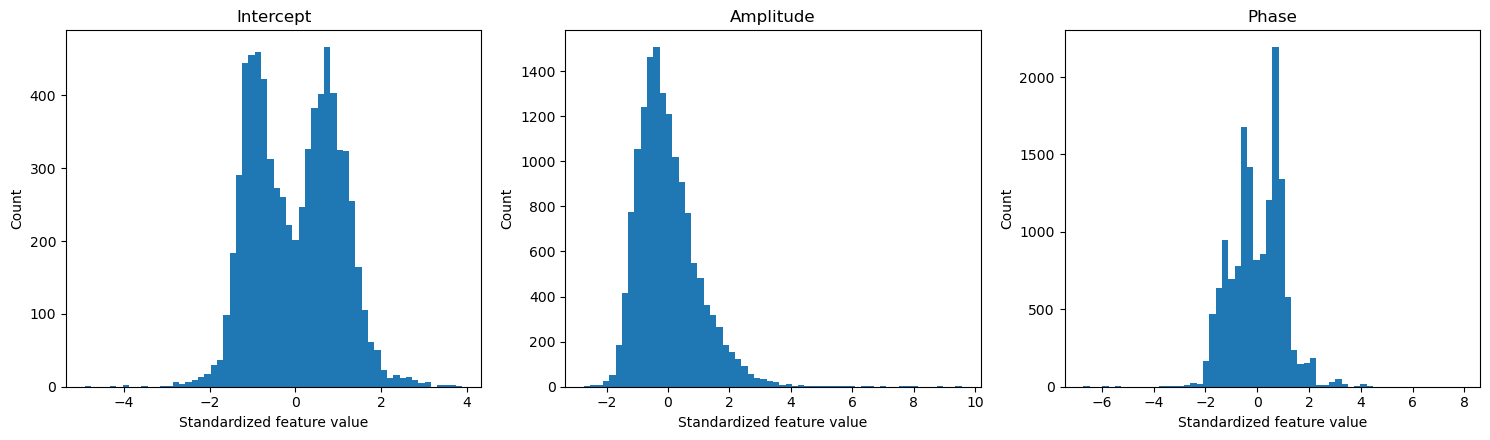

In [38]:
# ---------------------------------------------------------------------
# STANDARDIZED DISTRIBUTIONS BY FEATURE BLOCK
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)

for ax, (label, cols) in zip(
    axes,
    blocks.items(),
):

    X = (
        k2_model[cols]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy(dtype=float)
    )

    # standardize each feature independently
    Xz = (
        X - X.mean(axis=0)
    ) / X.std(axis=0)

    values = Xz.ravel()

    ax.hist(
        values,
        bins=60,
    )

    ax.set_title(label)
    ax.set_xlabel("Standardized feature value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()